In [1]:
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
cwd = pathlib.Path('/Users/rgao76/Documents/DiffTasks/effect_estimation_2025')

In [2]:
def brighten_hex_color(hex_color, alpha):
    # Convert hex to RGB
    r = int(hex_color[1:3], 16)
    g = int(hex_color[3:5], 16)
    b = int(hex_color[5:7], 16)

    # Brighten each channel
    r_new = int(r + (255 - r) * alpha)
    g_new = int(g + (255 - g) * alpha)
    b_new = int(b + (255 - b) * alpha)

    # Clamp to [0, 255] and convert back to hex
    return '#{:02x}{:02x}{:02x}'.format(min(r_new, 255), min(g_new, 255), min(b_new, 255))

In [10]:
data = pd.read_csv(cwd / 'Data' / 'all_data.csv')
data = data[~data['ROI'].str.contains('AngG')]
data['Version'] = data['Version'].fillna('')

def process_data(df, hemisphere=None, system=None, localizer=None, 
                 include_localizer=False, include_ROI=False):
    mask = (df['System'] == system)
    if hemisphere:
        mask &= (df['Hemisphere'] == hemisphere)
    if localizer:
        mask &= (df['Localizer'] == localizer)

    df_filtered = df[mask].copy()
    df_filtered['Task_Effect'] = (df_filtered['Version'] + ' ' + df_filtered['Effect']).str.strip()

    group_cols = ['System', 'Subject', 'Task_Effect']
    if include_localizer:
        group_cols.append('Localizer')
    if include_ROI:
        group_cols.append('ROI')

    return df_filtered[group_cols + ['EffectSize']].groupby(group_cols).mean().reset_index()

data_language_lh_localizers = process_data(data, hemisphere='LH', system='Language', include_localizer=True)
data_language_rh_localizers = process_data(data, hemisphere='RH', system='Language', include_localizer=True)
data_language_lh_ROI = process_data(data, hemisphere='LH', system='Language', include_ROI=True)
data_language_lh = process_data(data, hemisphere='LH', system='Language', localizer='V1')
data_language_rh = process_data(data, hemisphere='RH', system='Language', localizer='V1')
data_md_lh       = process_data(data, hemisphere='LH', system='MD')
data_md_rh       = process_data(data, hemisphere='RH', system='MD')

In [11]:
data_language_lh

,System,Subject,Task_Effect,EffectSize
0,Language,212,E,-0.197139
1,Language,212,H,-0.588259
2,Language,212,V1 N,-0.051931
3,Language,212,V1 S,1.766124
4,Language,212,V2 N,0.631228
...,...,...,...,...
545,Language,866,V3 S,1.335122
546,Language,866,V4 N,0.665662
547,Language,866,V4 S,3.426676
548,Language,866,V6 N,0.804806


In [12]:
beh_data

,Subject,Session,Version,Condition,Set,Run,Trial,Onset,Task,Sentence,Sentence_Type,Probe_or_Question,Response,RT,Response_Rate,Accuracy_Strict,Accuracy_Lax
0,864,FED20220203a_3T2,6,S,1,1,1,16.761347,ButtonPress,"Yes, I was held up a bit trying to make a left...",TwoSentences,NaN,1.0,0.616435,1.0,True,True
1,864,FED20220203a_3T2,6,S,1,1,2,25.728691,ButtonPress,"Yes, this conformity represents a desperate at...",TwoSentences,NaN,1.0,0.435774,1.0,True,True
2,864,FED20220203a_3T2,6,S,1,1,3,34.730480,ButtonPress,"Yes, the reporter nodded as he moved up beside...",TwoSentences,NaN,1.0,0.467579,1.0,True,True
3,864,FED20220203a_3T2,6,N,1,1,4,41.114322,MemoryAll,Nonword_sequence,OneSentence,2.0,2.0,1.327379,1.0,True,True
4,864,FED20220203a_3T2,6,N,1,1,5,50.182712,MemoryAll,Nonword_sequence,OneSentence,1.0,1.0,0.884339,1.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21883,851,FED_20210929d_3T2,5,N,4,8,44,443.115496,MemoryAll,Nonword_sequence,OneSentence,2.0,2.0,1.397124,1.0,True,True
21884,851,FED_20210929d_3T2,5,N,4,8,45,452.116781,MemoryAll,Nonword_sequence,OneSentence,1.0,1.0,1.401042,1.0,True,True
21885,851,FED_20210929d_3T2,5,S,4,8,46,463.734795,Sentiment,"No, Curt was too involved in his own problems ...",TwoSentences,2.0,2.0,0.580249,1.0,True,True
21886,851,FED_20210929d_3T2,5,S,4,8,47,472.736339,Sentiment,"Yes, I knew in that moment that I did not have...",TwoSentences,NaN,1.0,0.980910,1.0,NaN,NaN


In [19]:
hue_order = ['V1 S', 'V1 N', 'V2 S', 'V2 N', 'V3 S', 'V3 N', 'V6 S', 'V6 N', 'V4 S', 'V4 N', 'V5 S', 'V5 N']
all_colors_expanded = ["#606060", brighten_hex_color("#606060", 0.4), 
                       "#0000ff", brighten_hex_color("#0000ff", 0.7), 
                       "#00aaff", brighten_hex_color("#00aaff", 0.7), 
                       "#606060", brighten_hex_color("#0000ff", 0.7),
                       "#ff007f", brighten_hex_color("#0000ff", 0.7), 
                       "#ff6e00", brighten_hex_color("#0000ff", 0.7), 
                       ]
localizer_renaming = {
    'V1': 'V1 (button press)',
    'V2': 'V2 (hard memory probe)',
    'V3': 'V3 (easy memory probe)',
    'V4': 'V5 (comprehension q)',
    'V5': 'V6 (sentiment q)',
    'V6': 'V4 (button press)',
}
order = ['V2 (hard memory probe)', 'V3 (easy memory probe)', 
         'V4 (button press)',  'V5 (comprehension q)', 'V6 (sentiment q)']

header_sz = 10
axis_label_sz = 6
stripplot_sz = 1.0
annot_height = 1
jitter = 0.2

Set 1: 10 unique subjects
Set 2: 12 unique subjects
Set 3: 10 unique subjects
Set 4: 11 unique subjects
Set 5: 9 unique subjects


/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_21528/2822677897.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'Set {i}' for i in range(1, 6)], fontsize=8)


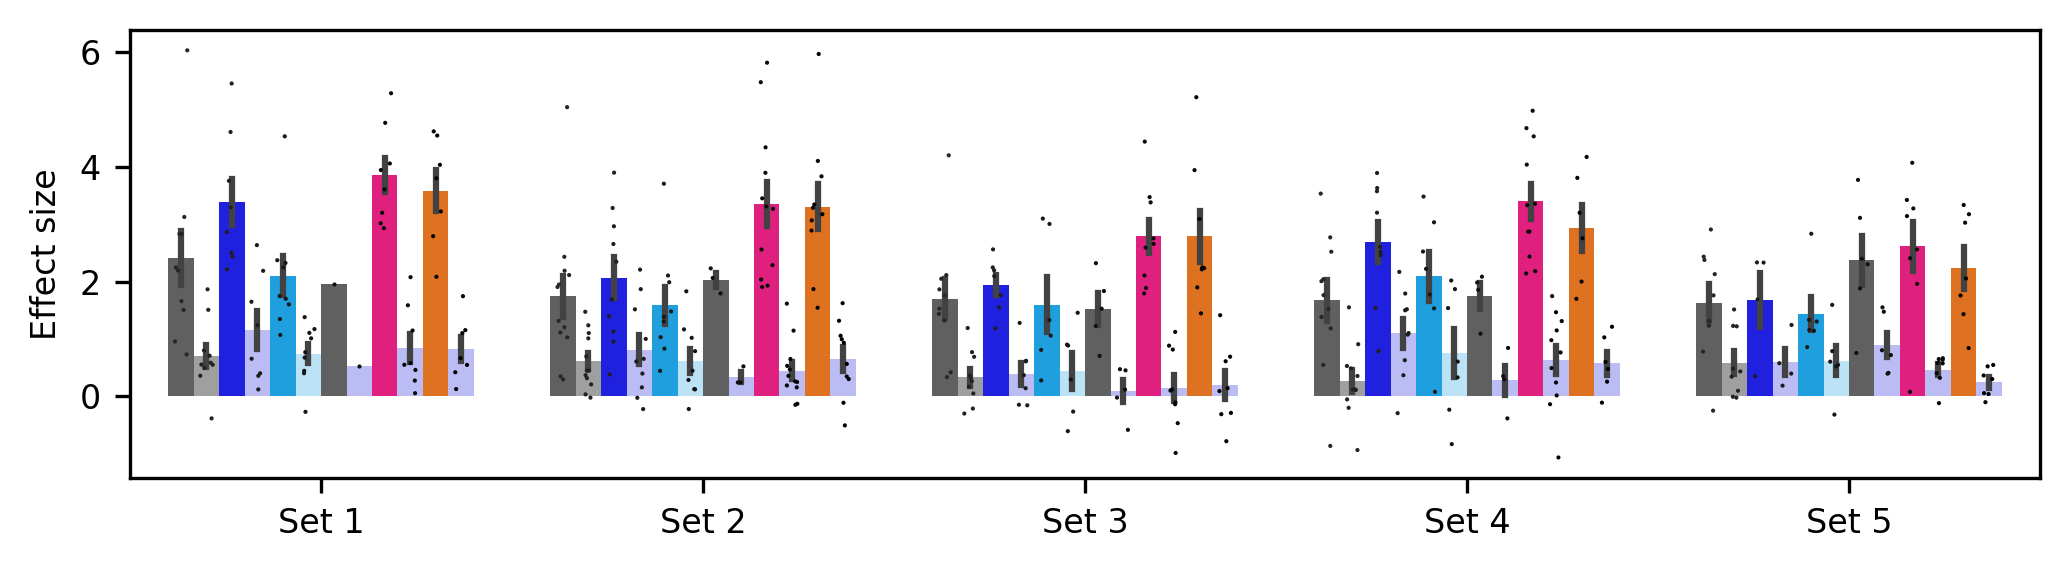

In [31]:
data_language_lh_withSet = data_language_lh.copy()
beh_data = pd.read_csv(cwd / '..' / 'behavioral_analysis_2025' / 'qc' / 'Data' / 'processed_data_by_trial.csv')
beh_data = beh_data[beh_data['Version'] == 1]
data_language_lh_withSet = data_language_lh_withSet.merge(beh_data[['Subject', 'Set']].drop_duplicates(), on='Subject', how='left')

plt.figure(figsize=(7, 2), tight_layout=True, dpi=300)
ax = sns.barplot(
    x='Set', y='EffectSize', hue='Task_Effect', 
    data=data_language_lh_withSet, 
    legend=False, errorbar='se',
    palette=all_colors_expanded, hue_order=hue_order,
    err_kws={'linewidth': 1.5})
sns.stripplot(
    x='Set', y='EffectSize', hue='Task_Effect', 
    data=data_language_lh_withSet, 
    dodge=True, jitter=jitter, legend=False, 
    size=stripplot_sz, palette='dark:black',
    hue_order=hue_order)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.ylabel("Effect size", fontsize=8)
plt.xlabel("", fontsize=axis_label_sz)
ax.set_xticklabels([f'Set {i}' for i in range(1, 6)], fontsize=8)
plt.savefig(cwd / 'Figures' / 'effects_V1_bySet.png', dpi=300, format='png',
            transparent=True)

# print the number of unique subjects in each set
for set_num in range(1, 6):
    num_subjects = data_language_lh_withSet[data_language_lh_withSet['Set'] == set_num]['Subject'].nunique()
    print(f'Set {set_num}: {num_subjects} unique subjects')

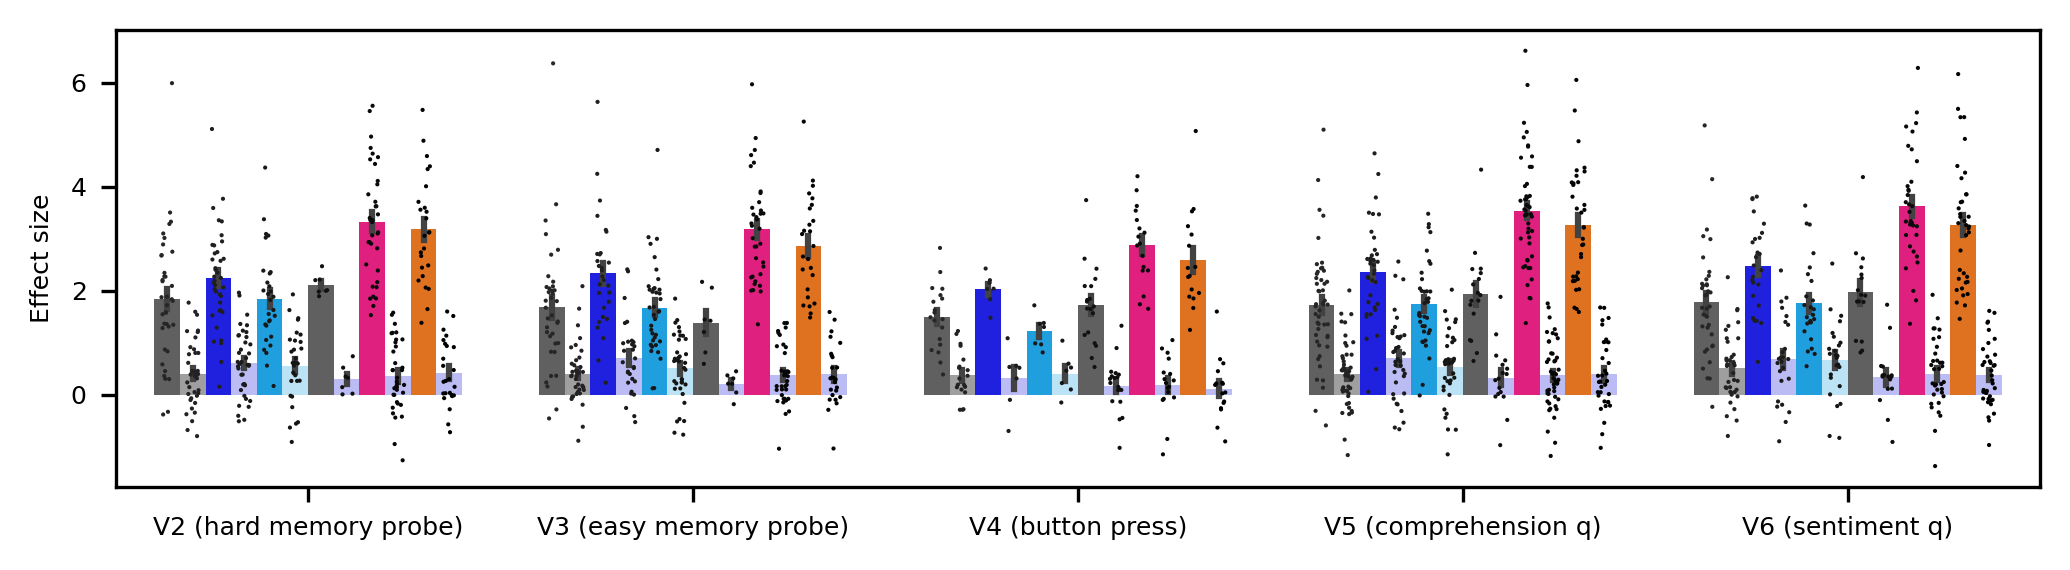

In [5]:
# Localizers
plt.figure(figsize=(7, 2), tight_layout=True, dpi=300)
data_language_lh_localizers['Localizer'] = data_language_lh_localizers['Localizer'].replace(localizer_renaming)
ax = sns.barplot(
    x='Localizer', y='EffectSize', hue='Task_Effect', 
    data=data_language_lh_localizers, 
    legend=False, errorbar='se',
    palette=all_colors_expanded, hue_order=hue_order, order=order,
    err_kws={'linewidth': 1.5})
sns.stripplot(
    x='Localizer', y='EffectSize', hue='Task_Effect', 
    data=data_language_lh_localizers, 
    dodge=True, jitter=jitter, legend=False, 
    size=stripplot_sz, palette='dark:black',
    hue_order=hue_order, order=order)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.ylabel("Effect size", fontsize=axis_label_sz)
plt.xlabel("", fontsize=axis_label_sz)
plt.savefig(cwd / 'Figures' / 'effects_localizers.png', dpi=300, format='png',
            transparent=True)


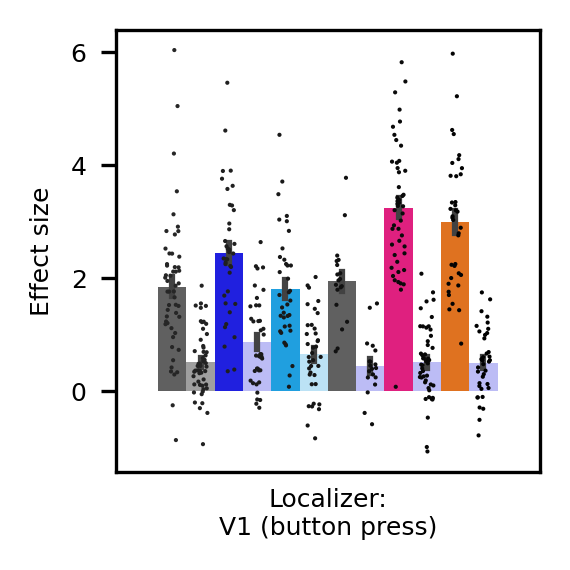

In [7]:
# V1
plt.figure(figsize=(2, 2), tight_layout=True, dpi=300)
data_language_lh['Localizer'] = 'V1'

ax = sns.barplot(
    x='Localizer', y='EffectSize', hue='Task_Effect', 
    data=data_language_lh, legend=False, errorbar='se',
    palette=all_colors_expanded, hue_order=hue_order,
    err_kws={'linewidth': 1.5})
sns.stripplot(
    x='Localizer', y='EffectSize', hue='Task_Effect', 
    data=data_language_lh, 
    dodge=True, jitter=jitter, legend=False, 
    size=stripplot_sz, palette='dark:black',
    hue_order=hue_order)

plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.ylabel("Effect size", fontsize=axis_label_sz)
plt.xlabel("Localizer:\nV1 (button press)", fontsize=axis_label_sz)
plt.xticks([])
plt.savefig(cwd / 'Figures' / 'effects_V1.png', dpi=300, format='png',
            transparent=True)

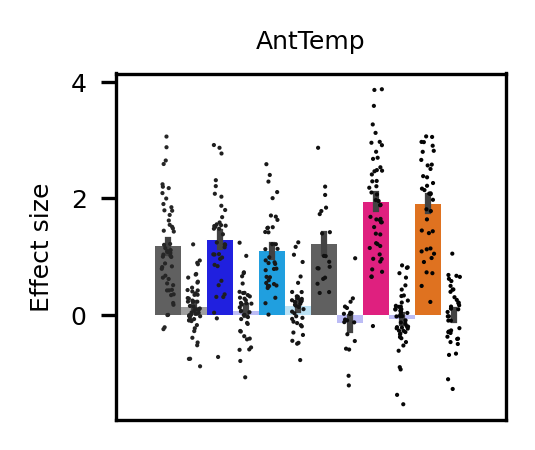

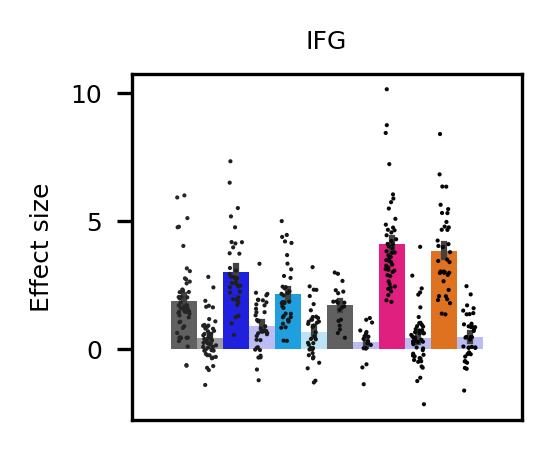

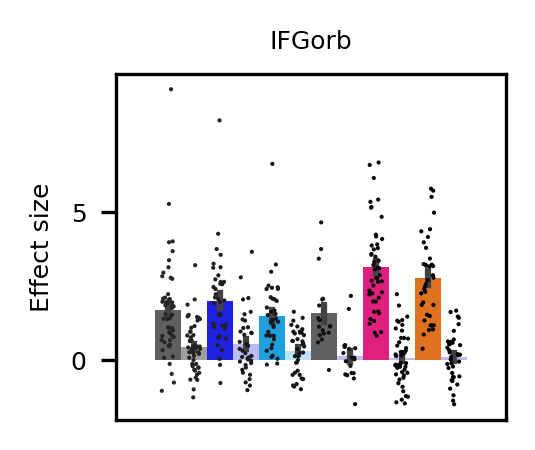

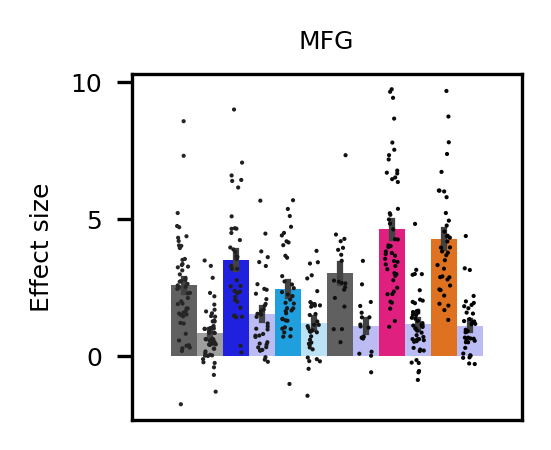

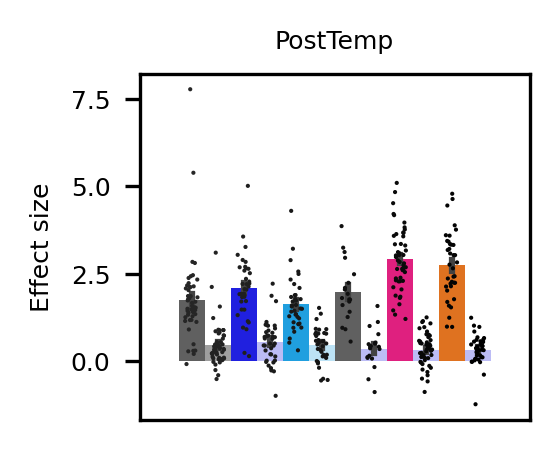

In [8]:
# ROI
for roi in data_language_lh_ROI['ROI'].unique():
    fig = plt.figure(figsize=(2, 1.5), dpi=300)

    data_subset = data_language_lh_ROI[data_language_lh_ROI['ROI'] == roi]
    data_subset_mean = data_subset[['Subject', 'Task_Effect', 'EffectSize']].groupby(
        ['Subject', 'Task_Effect']
    ).mean().reset_index()
    data_subset_mean['Localizer'] = 'V1'

    ax = sns.barplot(
        x='Localizer', y='EffectSize', hue='Task_Effect', 
        data=data_subset_mean, legend=False, errorbar='se',
        palette=all_colors_expanded, hue_order=hue_order,
        err_kws={'linewidth': 1.5})
    sns.stripplot(
        x='Localizer', y='EffectSize', hue='Task_Effect', 
        data=data_subset_mean, dodge=True, jitter=jitter, legend=False, 
        size=stripplot_sz, palette='dark:black',
        hue_order=hue_order)

    # change xticks size
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

    plt.ylabel("Effect size", fontsize=axis_label_sz)
    plt.xlabel(None, fontsize=axis_label_sz)
    plt.xticks([])
    plt.title(roi.replace('LH_', ''), fontsize=axis_label_sz)
    fig.subplots_adjust(left=0.25)
    plt.savefig(cwd / 'Figures' / f'effects_{roi}.png', dpi=300, format='png',
                transparent=True)

/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/2275718132.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect1 = Rectangle((label_width, y_pos), box_width, box_height,
/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/2275718132.py:42: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect2 = Rectangle((label_width + box_width + gap_between_columns, y_pos),


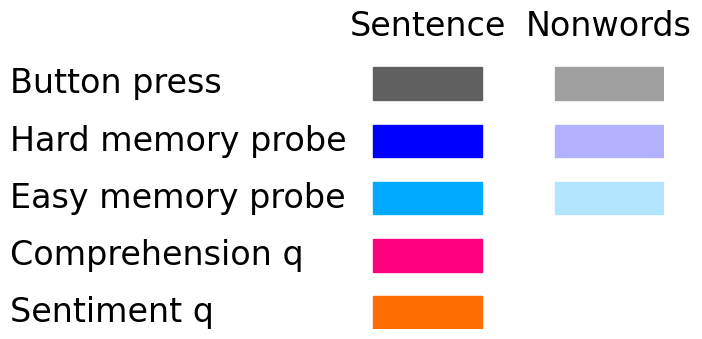

In [9]:
from matplotlib.patches import Rectangle

colors_s = ['#606060', '#0000ff', '#00aaff', '#ff007f', '#ff6e00']
labels = ['Button press', 
          'Hard memory probe', 
          'Easy memory probe', 
          'Comprehension q', 
          'Sentiment q']
colors_col2 = colors_s[:3] + [None, None]  # Repeat first 3, leave last 2 blank

# Parameters
box_width = 1.2
box_height = 0.4
margin = 0.3
label_width = 4
gap_between_columns = 0.8

total_rows = len(colors_s)
total_height = total_rows * (box_height + margin)
total_width = label_width + 2 * box_width + gap_between_columns

fig, ax = plt.subplots(figsize=(total_width, total_height))

# Draw label column and first color column
for i, (label, color) in enumerate(zip(labels, colors_s)):
    y_pos = total_height - (i + 1) * (box_height + margin)

    # Label
    ax.text(label_width - 4, y_pos + box_height / 2, label,
            ha='left', va='center', fontsize=24)

    # First column rectangle
    rect1 = Rectangle((label_width, y_pos), box_width, box_height,
                      color=color, edgecolor='black')
    ax.add_patch(rect1)

# Draw second column
for i, color in enumerate(colors_col2):
    y_pos = total_height - (i + 1) * (box_height + margin)
    if color is not None:
        color = brighten_hex_color(color, 0.4) if color == '#606060' else brighten_hex_color(color, 0.7)
        rect2 = Rectangle((label_width + box_width + gap_between_columns, y_pos),
                          box_width, box_height, color=color, edgecolor='black')
        ax.add_patch(rect2)

# Set limits and remove axes
ax.set_xlim(0, total_width)
ax.set_ylim(0, total_height)
ax.axis('off')

# Add column headers
header_y = total_height  # Slightly above the top row
ax.text(label_width + box_width / 2, header_y, "Sentence", ha='center', va='bottom', fontsize=24)
ax.text(label_width + box_width + gap_between_columns + box_width / 2, header_y, "Nonwords", ha='center', va='bottom', fontsize=24)

plt.tight_layout()
plt.savefig(cwd / 'Figures' / 'color_legend.png', dpi=300, format='png', 
            transparent=True)

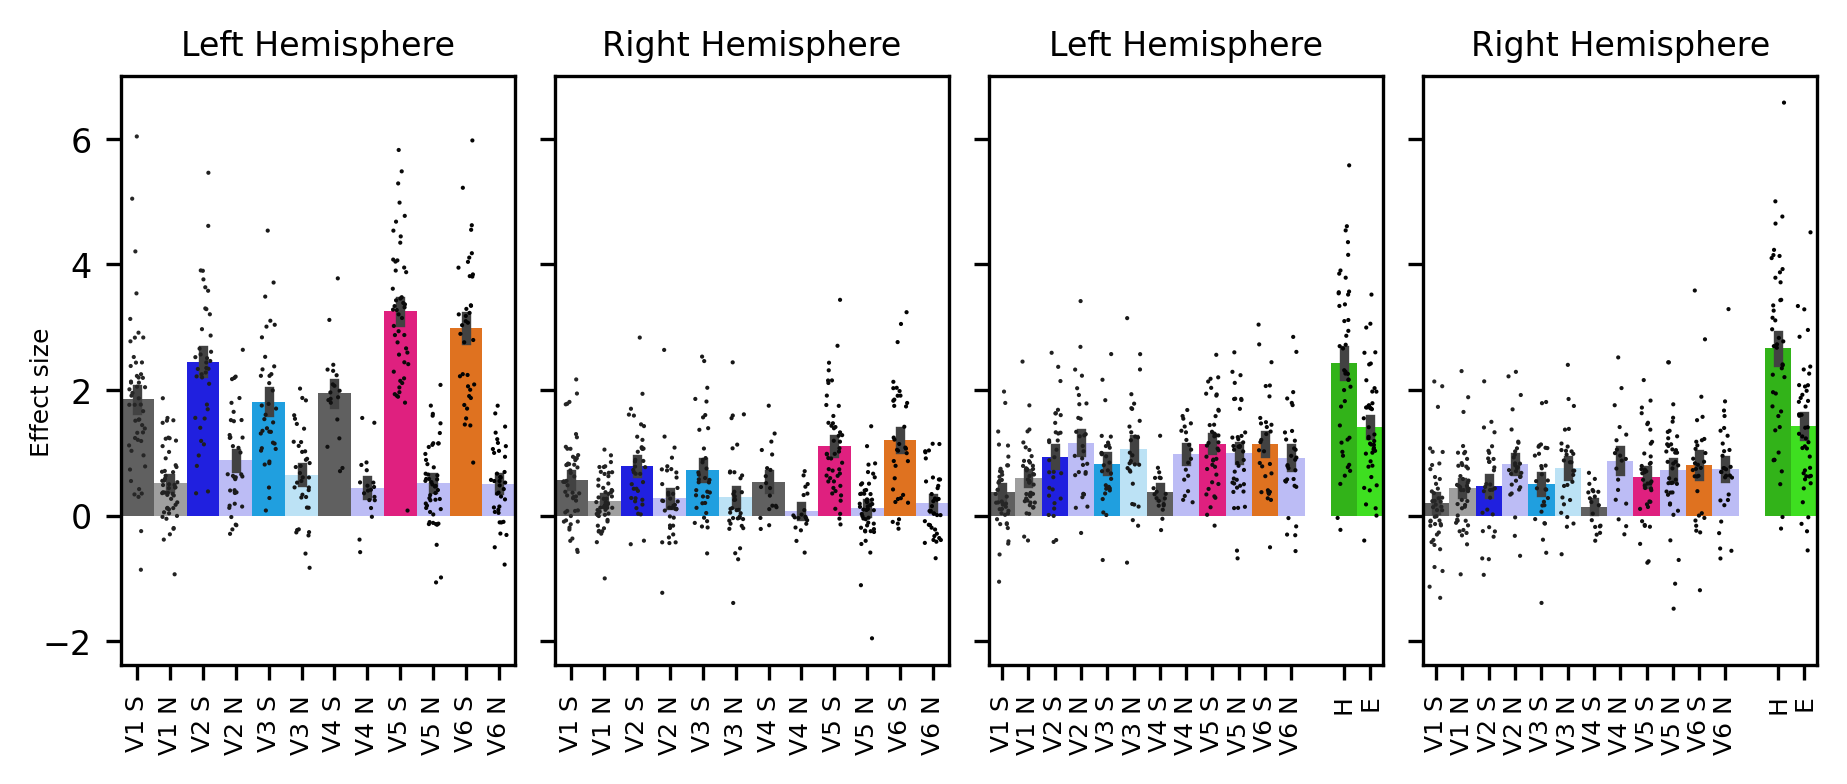

In [10]:
# Left to right: Langauge LH, Language RH, MD LH, MD RH
def plot_bar_with_strip(ax, data, palette, hue_order_labels_local, hue_order_plot, 
                        is_grouped=False, title=None):
    sns.barplot(x='System', y='EffectSize', hue='Task_Effect', data=data,
                ax=ax, legend=False, errorbar='se',
                palette=palette, hue_order=hue_order_plot)
    sns.stripplot(x='System', y='EffectSize', hue='Task_Effect', data=data,
                  dodge=True, jitter=jitter, legend=False, size=stripplot_sz,
                  ax=ax, palette='dark:black',
                  hue_order=hue_order_plot)

    bar_centers = [bar.get_x() + bar.get_width() / 2 for bar in ax.patches]
    ax.set_xticks([])
    ax.set_xticks(bar_centers)
    ax.set_xticklabels(hue_order_labels_local, rotation=90)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=6)
    ax.set_xlim(ax.patches[0].get_x(), ax.patches[-1].get_x() + ax.patches[-1].get_width())

    if title:
        ax.set_title(title, fontsize=header_sz-2, pad=5)


# Adjust hue_order labels
hue_order_labels = [label.replace('V6', 'V1b').replace('V5', 'V6').replace('V4', 'V5').replace('V1b', 'V4')  for label in hue_order]

# Setup figure
fig, axs = plt.subplots(1, 4, figsize=(6, 2.5), constrained_layout=True, dpi=300, sharey=True,
                        width_ratios=[1, 1, 1, 1])

# Plot Language LH
plot_bar_with_strip(
    axs[0], data_language_lh, 
    all_colors_expanded, 
    hue_order_labels, 
    hue_order,
    title='Left Hemisphere'
)

# Plot Language RH
plot_bar_with_strip(
    axs[1], data_language_rh, 
    all_colors_expanded, 
    hue_order_labels, 
    hue_order,
    title='Right Hemisphere'
)

# Plot MD LH
plot_bar_with_strip(
    axs[2], data_md_lh,
    all_colors_expanded + ['white', '#20CC00', '#28FF00'],
    hue_order_labels + ['H', 'E'],
    hue_order + ['placeholder', 'H', 'E'],
    title='Left Hemisphere'
)

# Plot MD RH
plot_bar_with_strip(
    axs[3], data_md_rh,
    all_colors_expanded + ['white', '#20CC00', '#28FF00'],
    hue_order_labels + ['H', 'E'],
    hue_order + ['placeholder', 'H', 'E'],
    title='Right Hemisphere'
)

# Final layout and save
fig.supylabel("Effect size", fontsize=axis_label_sz, x=0.)
fig.savefig(cwd / 'Figures' / 'effects_networks.png', dpi=300, format='png', 
            bbox_inches='tight', transparent=True)


/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/3553818181.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = Rectangle((x_pos, 0), 1.2, 0.4, color=color, edgecolor='black')


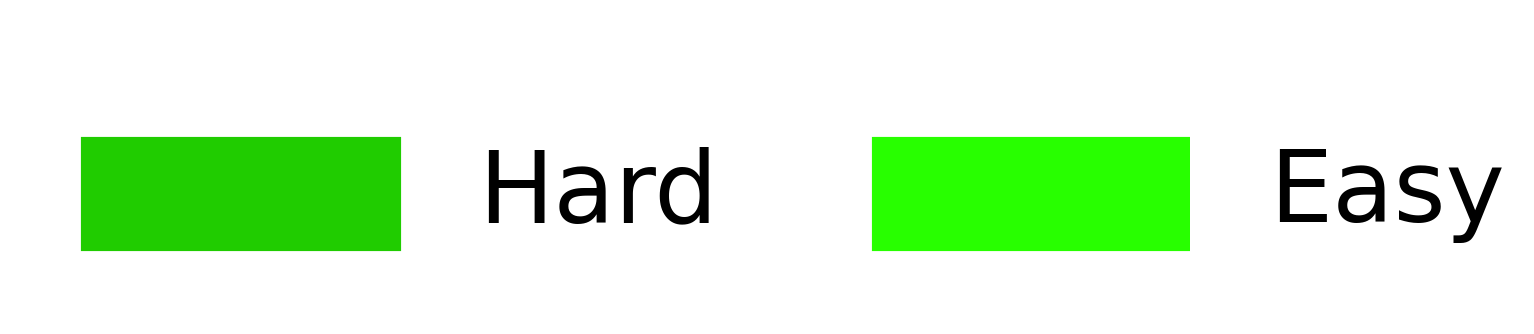

In [11]:
# Color legend for MD
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(5, 1), dpi=300, constrained_layout=True)

colors = ['#20CC00', '#28FF00']
labels = ['Hard', 'Easy']

for i, (color, label) in enumerate(zip(colors, labels)):
    x_pos = i * 3  # spacing between blocks
    rect = Rectangle((x_pos, 0), 1.2, 0.4, color=color, edgecolor='black')
    ax.add_patch(rect)
    ax.text(x_pos + 1.5, 0.2, label, fontsize=24, va='center')

ax.set_xlim(-0.2, 4.2)
ax.set_ylim(-0.2, 0.8)
ax.axis('off')

plt.savefig(cwd / 'Figures' / 'color_legend_MD.png', dpi=300, format='png', 
            transparent=True)


In [12]:
# print the number of subjects for each localizer:
for localizer in data_language_lh_localizers['Localizer'].unique():
    n_subjects = data_language_lh_localizers[
        data_language_lh_localizers['Localizer'] == localizer
    ]['Subject'].nunique()
    print(f"{localizer}: {n_subjects} subjects")

V1 (button press): 52 subjects
V2 (hard memory probe): 38 subjects
V3 (easy memory probe): 37 subjects
V5 (comprehension q): 48 subjects
V6 (sentiment q): 37 subjects
V4 (button press): 19 subjects


In [13]:
# first, only keep tasks_effect where there is 'S' or 'N' in the string, and recode them as 'S' and 'N'
data_language_lh_copy = data_language_lh_localizers.copy()
data_language_lh_copy_s = data_language_lh_copy[
    data_language_lh_copy['Task_Effect'].str.contains('S')
]
data_language_lh_copy_s['Task_Effect'] = 'S'
data_language_lh_copy_n = data_language_lh_copy[
    data_language_lh_copy['Task_Effect'].str.contains('N')
]
data_language_lh_copy_n['Task_Effect'] = 'N'
data_language_lh_copy_s['EffectSize'].mean() / data_language_lh_copy_n['EffectSize'].mean(), data_language_lh_copy_s['EffectSize'].mean(), data_language_lh_copy_n['EffectSize'].mean()

/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/2540105175.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_language_lh_copy_s['Task_Effect'] = 'S'
/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/2540105175.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_language_lh_copy_n['Task_Effect'] = 'N'


(np.float64(5.0761112189779025),
 np.float64(2.4088415690408356),
 np.float64(0.4745446790123457))

In [14]:
data_language_lh_copy_s

,System,Subject,Task_Effect,Localizer,EffectSize
12,Language,212,S,V1 (button press),1.766124
13,Language,212,S,V2 (hard memory probe),1.545917
14,Language,212,S,V3 (easy memory probe),1.972551
15,Language,212,S,V5 (comprehension q),1.738207
20,Language,212,S,V1 (button press),2.521498
...,...,...,...,...,...
2483,Language,866,S,V4 (button press),2.905533
2488,Language,866,S,V1 (button press),2.400271
2489,Language,866,S,V3 (easy memory probe),1.445750
2490,Language,866,S,V5 (comprehension q),2.422829


In [17]:
# for each Localizer, S/N
for localizer in data_language_lh_localizers['Localizer'].unique():
    data_subset = data_language_lh_localizers[
        data_language_lh_localizers['Localizer'] == localizer
    ]
    data_s = data_subset[
        data_subset['Task_Effect'].str.contains('S')
    ]
    data_s['Task_Effect'] = 'S'
    data_n = data_subset[
        data_subset['Task_Effect'].str.contains('N')
    ]
    data_n['Task_Effect'] = 'N'
    ratio = data_s['EffectSize'].mean() / data_n['EffectSize'].mean()
    mean_s = data_s['EffectSize'].mean()
    mean_n = data_n['EffectSize'].mean()
    print(f"{localizer}: S/N ratio = {ratio:.2f}, Mean S = {mean_s:.3f}, Mean N = {mean_n:.3f}")

V1 (button press): S/N ratio = 4.12, Mean S = 2.424, Mean N = 0.588
V2 (hard memory probe): S/N ratio = 5.29, Mean S = 2.445, Mean N = 0.462
V3 (easy memory probe): S/N ratio = 4.92, Mean S = 2.266, Mean N = 0.461
V5 (comprehension q): S/N ratio = 5.47, Mean S = 2.487, Mean N = 0.455
V6 (sentiment q): S/N ratio = 5.26, Mean S = 2.570, Mean N = 0.489
V4 (button press): S/N ratio = 8.55, Mean S = 2.049, Mean N = 0.240


/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/4259206970.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_s['Task_Effect'] = 'S'
/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/4259206970.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_n['Task_Effect'] = 'N'


In [16]:
# first, only keep tasks_effect where there is 'S' or 'N' in the string, and recode them as 'S' and 'N'
data_language_rh_copy = data_language_rh_localizers.copy()
data_language_rh_copy_s = data_language_rh_copy[
    data_language_rh_copy['Task_Effect'].str.contains('S')
]
data_language_rh_copy_s['Task_Effect'] = 'S'
data_language_rh_copy_n = data_language_rh_copy[
    data_language_rh_copy['Task_Effect'].str.contains('N')
]
data_language_rh_copy_n['Task_Effect'] = 'N'
data_language_rh_copy_s['EffectSize'].mean() / data_language_rh_copy_n['EffectSize'].mean(), data_language_rh_copy_s['EffectSize'].mean(), data_language_rh_copy_n['EffectSize'].mean()

/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/2363043349.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_language_rh_copy_s['Task_Effect'] = 'S'
/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_708/2363043349.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_language_rh_copy_n['Task_Effect'] = 'N'


(np.float64(5.922648382405237),
 np.float64(0.835588988414055),
 np.float64(0.14108367312440645))